In [12]:
# !pip uninstall -y numpy
# !pip install numpy==1.26.4

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, sosfreqz
import os

In [ ]:
__file__ = 'data_filtering.ipynb'
_rootDir = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))


'/Users/earanda/Documents/GitHub/ucsd-brain-to-music-interface'

In [8]:
music_eeg_df = pd.read_csv(os.path.join(_rootDir, 'data', 'raw', 'enrique526_DB-BMI_trial0_taylor swift - lavender haze_eeg.csv'))
music_eeg_df['timestamp_s'] = music_eeg_df['timestamp_s'] - music_eeg_df['timestamp_s'].iloc[0]
music_eeg_df.head()

,timestamp_s,ch1_uV,ch2_uV,ch3_uV,ch4_uV,ch5_uV,ch6_uV,ch7_uV,ch8_uV,ch9_uV,ch10_uV,ch11_uV,ch12_uV,ch13_uV,ch14_uV,ch15_uV,ch16_uV
0,0.000000,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,-120445.7734,-119943.5078,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0
1,0.003998,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,-120855.3672,-120227.5547,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0
2,0.007998,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,-120139.2188,-119964.1797,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0
3,0.012002,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,-119964.0000,-119785.3672,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0
4,0.016006,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,-119698.5078,-119576.0234,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0


In [9]:
global_baseline_eeg_df = pd.read_csv(os.path.join(_rootDir, 'data', 'raw', 'enrique526_DB-BMI_60s_baseline_eeg.csv'))
global_baseline_eeg_df['timestamp_s'] = global_baseline_eeg_df['timestamp_s'] - global_baseline_eeg_df['timestamp_s'].iloc[0]  
global_baseline_eeg_df.head()


,timestamp_s,ch1_uV,ch2_uV,ch3_uV,ch4_uV,ch5_uV,ch6_uV,ch7_uV,ch8_uV,ch9_uV,ch10_uV,ch11_uV,ch12_uV,ch13_uV,ch14_uV,ch15_uV,ch16_uV
0,0.000000,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,-120329.0703,-120019.1484,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0
1,0.003972,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,-120768.5547,-119851.0156,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0
2,0.007972,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,-120612.2266,-120454.8281,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0
3,0.011965,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,-120301.2500,-120500.9609,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0
4,0.015958,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,-120720.3672,-120684.6641,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0,187500.0


In [12]:
# array of channels, from 1 to 16
channels = np.array(['FP1', 'FP2', 'F7', 'F3', 'F4', 'F8', 'T3', 'C3', 'C4', 'T4', 'T5', 'P3', 'P4', 'T6', 'O1', 'O2'])
for i in range(len(channels)):
    print(f'Channel {i+1} is {channels[i]}')

Channel 1 is FP1
Channel 2 is FP2
Channel 3 is F7
Channel 4 is F3
Channel 5 is F4
Channel 6 is F8
Channel 7 is T3
Channel 8 is C3
Channel 9 is C4
Channel 10 is T4
Channel 11 is T5
Channel 12 is P3
Channel 13 is P4
Channel 14 is T6
Channel 15 is O1
Channel 16 is O2


In [14]:
# rename channels to electrode placement

for i in range(len(channels)):
    music_eeg_df.rename(columns={f'ch{i+1}_uV': channels[i]}, inplace=True)
    # center data by subtracting mean

    print(f'{channels[i]} mean: {music_eeg_df[f"{channels[i]}"].mean()}')
    music_eeg_df[f'{channels[i]}'] = music_eeg_df[f'{channels[i]}'] - music_eeg_df[f'{channels[i]}'].mean()

print(music_eeg_df.head())

FP1 mean: 173745.68358813756
FP2 mean: 173861.7045672659
F7 mean: 173866.1665230978
F3 mean: 173915.71515977217
F4 mean: 174053.7137849655
F8 mean: 173871.44872738293
T3 mean: -105541.32051768395
C3 mean: -105699.7427430811
C4 mean: 173163.94019653008
T4 mean: 173240.63224451296
T5 mean: 173260.92702794733
P3 mean: 173198.0090203334
P4 mean: 173231.86854970214
T6 mean: 173130.1017858121
O1 mean: 173175.110820741
O2 mean: 173263.34493048704
   timestamp_s           FP1           FP2            F7           F3  \
0     0.000000  13754.316412  13638.295433  13633.833477  13584.28484   
1     0.003998  13754.316412  13638.295433  13633.833477  13584.28484   
2     0.007998  13754.316412  13638.295433  13633.833477  13584.28484   
3     0.012002  13754.316412  13638.295433  13633.833477  13584.28484   
4     0.016006  13754.316412  13638.295433  13633.833477  13584.28484   

             F4            F8            T3            C3            C4  \
0  13446.286215  13628.551273 -14904.45288

In [15]:
# rename channels to electrode placement

for i in range(len(channels)):
    global_baseline_eeg_df.rename(columns={f'ch{i+1}_uV': channels[i]}, inplace=True)
    # center data by subtracting mean

    print(f'{channels[i]} mean: {global_baseline_eeg_df[f"{channels[i]}"].mean()}')
    global_baseline_eeg_df[f'{channels[i]}'] = global_baseline_eeg_df[f'{channels[i]}'] - global_baseline_eeg_df[f'{channels[i]}'].mean()

print(global_baseline_eeg_df.head())

FP1 mean: 174158.60265114697
FP2 mean: 174149.08205575164
F7 mean: 174247.18639138725
F3 mean: 174243.47181885556
F4 mean: 174204.1984781699
F8 mean: 174492.4050645576
T3 mean: -116622.63700312578
C3 mean: -116343.10528310227
C4 mean: 172457.52961971262
T4 mean: 172449.47786517942
T5 mean: 172516.7115594656
P3 mean: 172446.34938687508
P4 mean: 172477.81983988738
T6 mean: 172358.8219022855
O1 mean: 172510.37034255947
O2 mean: 172488.45168029578
   timestamp_s           FP1           FP2            F7            F3  \
0     0.000000  13341.397349  13350.917944  13252.813609  13256.528181   
1     0.003972  13341.397349  13350.917944  13252.813609  13256.528181   
2     0.007972  13341.397349  13350.917944  13252.813609  13256.528181   
3     0.011965  13341.397349  13350.917944  13252.813609  13256.528181   
4     0.015958  13341.397349  13350.917944  13252.813609  13256.528181   

             F4            F8           T3           C3           C4  \
0  13295.801522  13007.594935 -3706

In [16]:
# define filters
# buttterworth filter aims to attenuate frequencies we are not interested in,
# while preserving the frequencies we are intested in

def butter_bandpass(lowcut, highcut, fs, order):
    nyq = fs/2
    low = lowcut /nyq
    high = highcut/nyq
    sos = butter(order, [low,high], analog=False, btype='band', output='sos')
    return sos

def butter_bandpass_filter(data, lowcut, highcut, fs, order):
    sos = butter_bandpass(lowcut, highcut, fs, order=order)
    y = sosfiltfilt(sos, data)
    return y



In [17]:
# filtering parameters
# from COGS 189 A1
fs = 500
lowcut = 0.1
highcut = 30

# lowcut_temp = 20
# highcut_temp = 40
# plt.figure(0)
# plt.clf()
# plt.plot([0, lowcut_temp], [0,0], 'b-')
# plt.plot([lowcut_temp, lowcut_temp], [0,1], 'b-')
# plt.plot([lowcut_temp, highcut_temp], [1,1], 'b-')
# plt.plot([highcut_temp, highcut_temp], [1,0], 'b-')
# plt.plot([highcut_temp, 100], [0,0], 'b-', label='ideal filter')
# plt.grid(True)
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Gain')
# plt.legend(loc='best')
# plt.title('Ideal Bandpass Filter')
# plt.show()

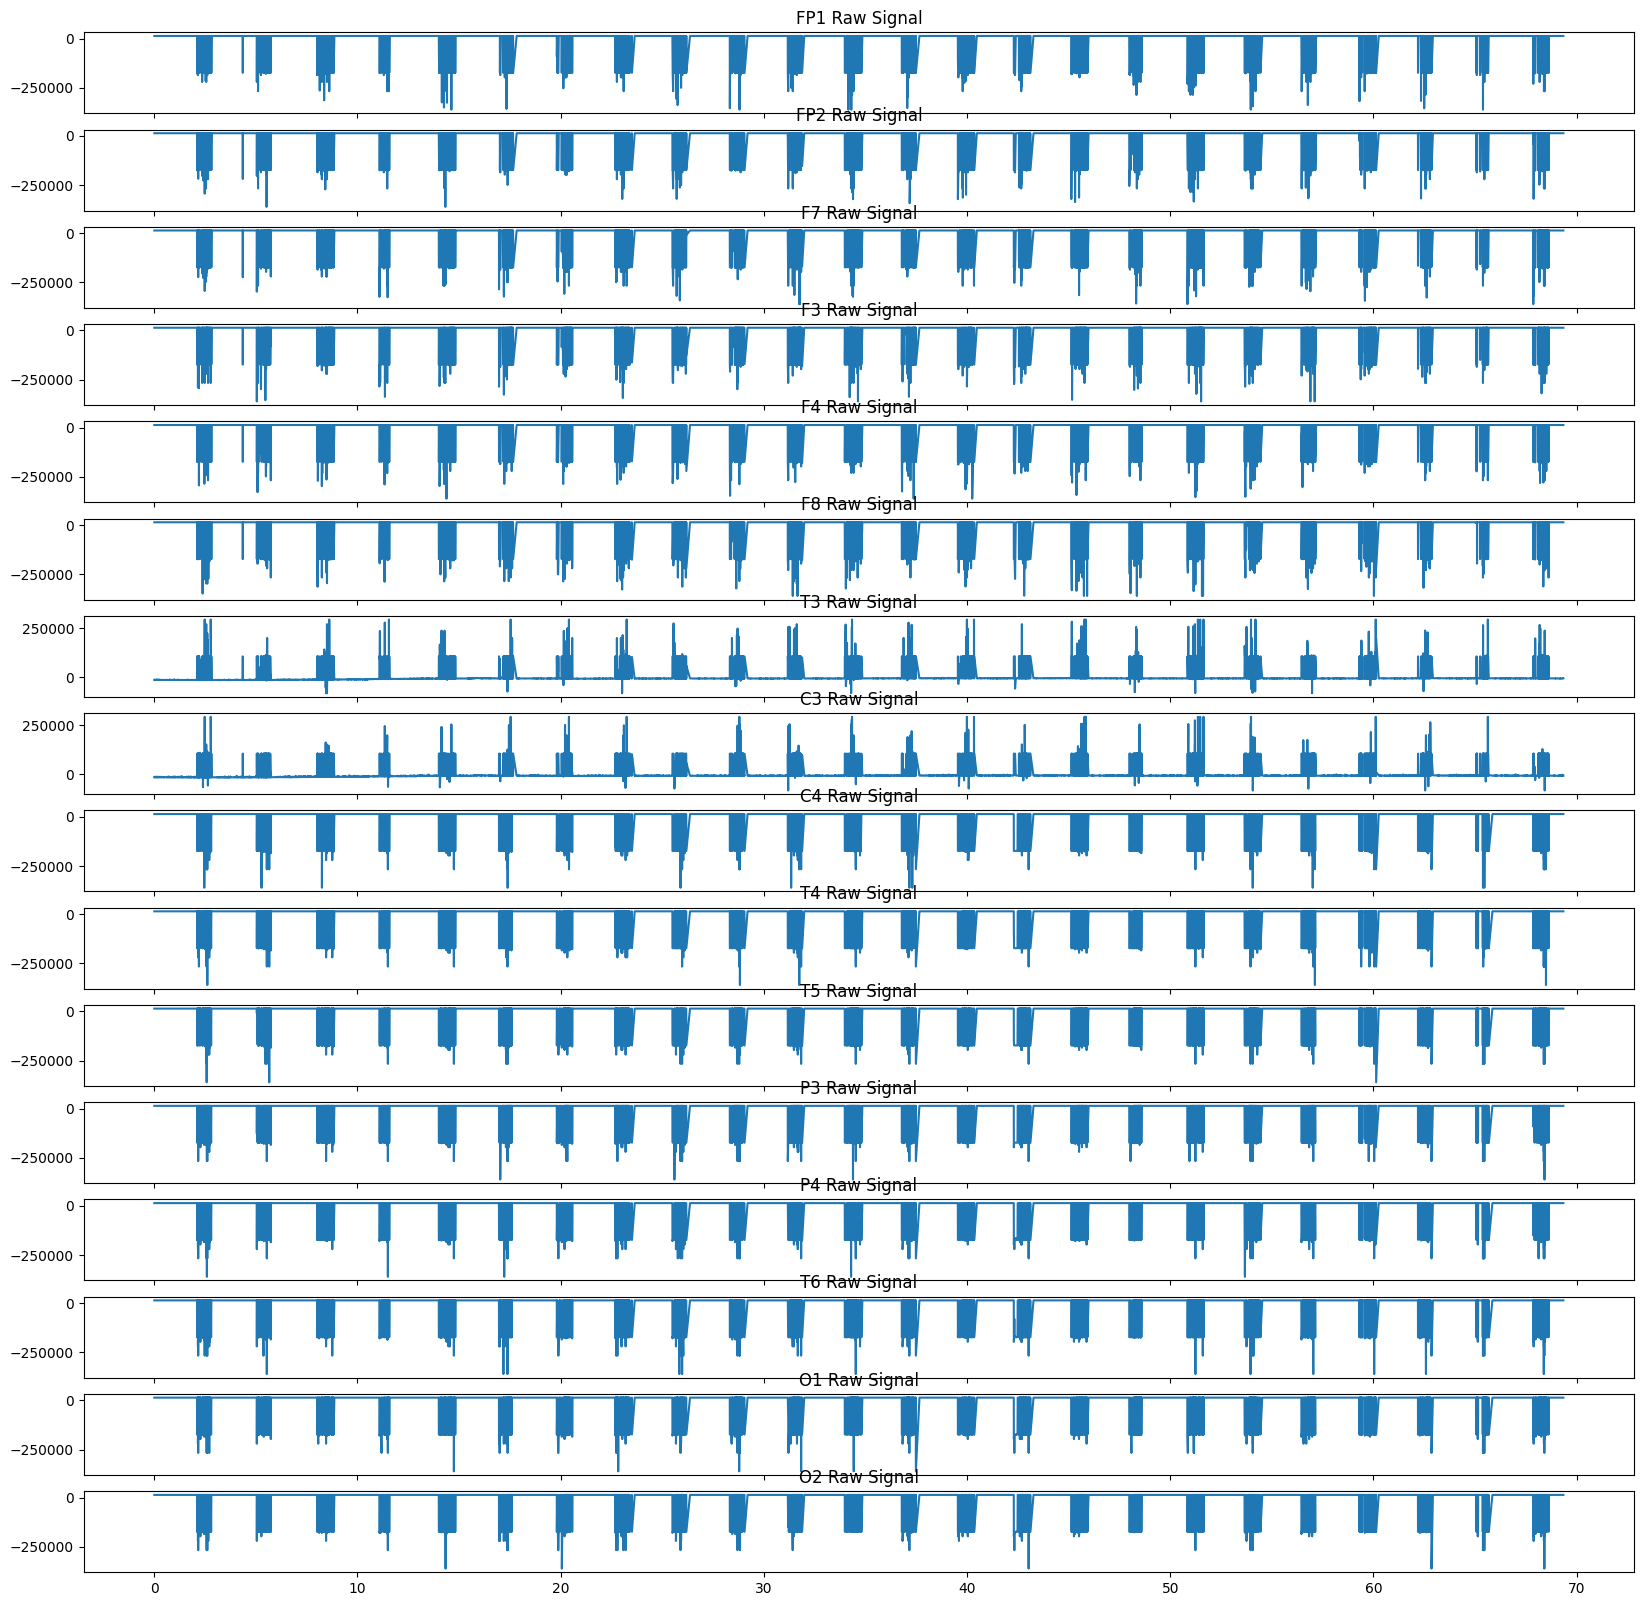

In [25]:
# 17906 time stamps, 16 channels + timestamp
music_eeg_df.shape
fig, axes = plt.subplots(16,1, figsize=(20,20), sharex=True)
for i in range(len(channels)):
    axes[i].plot(music_eeg_df['timestamp_s'], music_eeg_df[f'{channels[i]}'])
    axes[i].set_title(f'{channels[i]} Raw Signal')

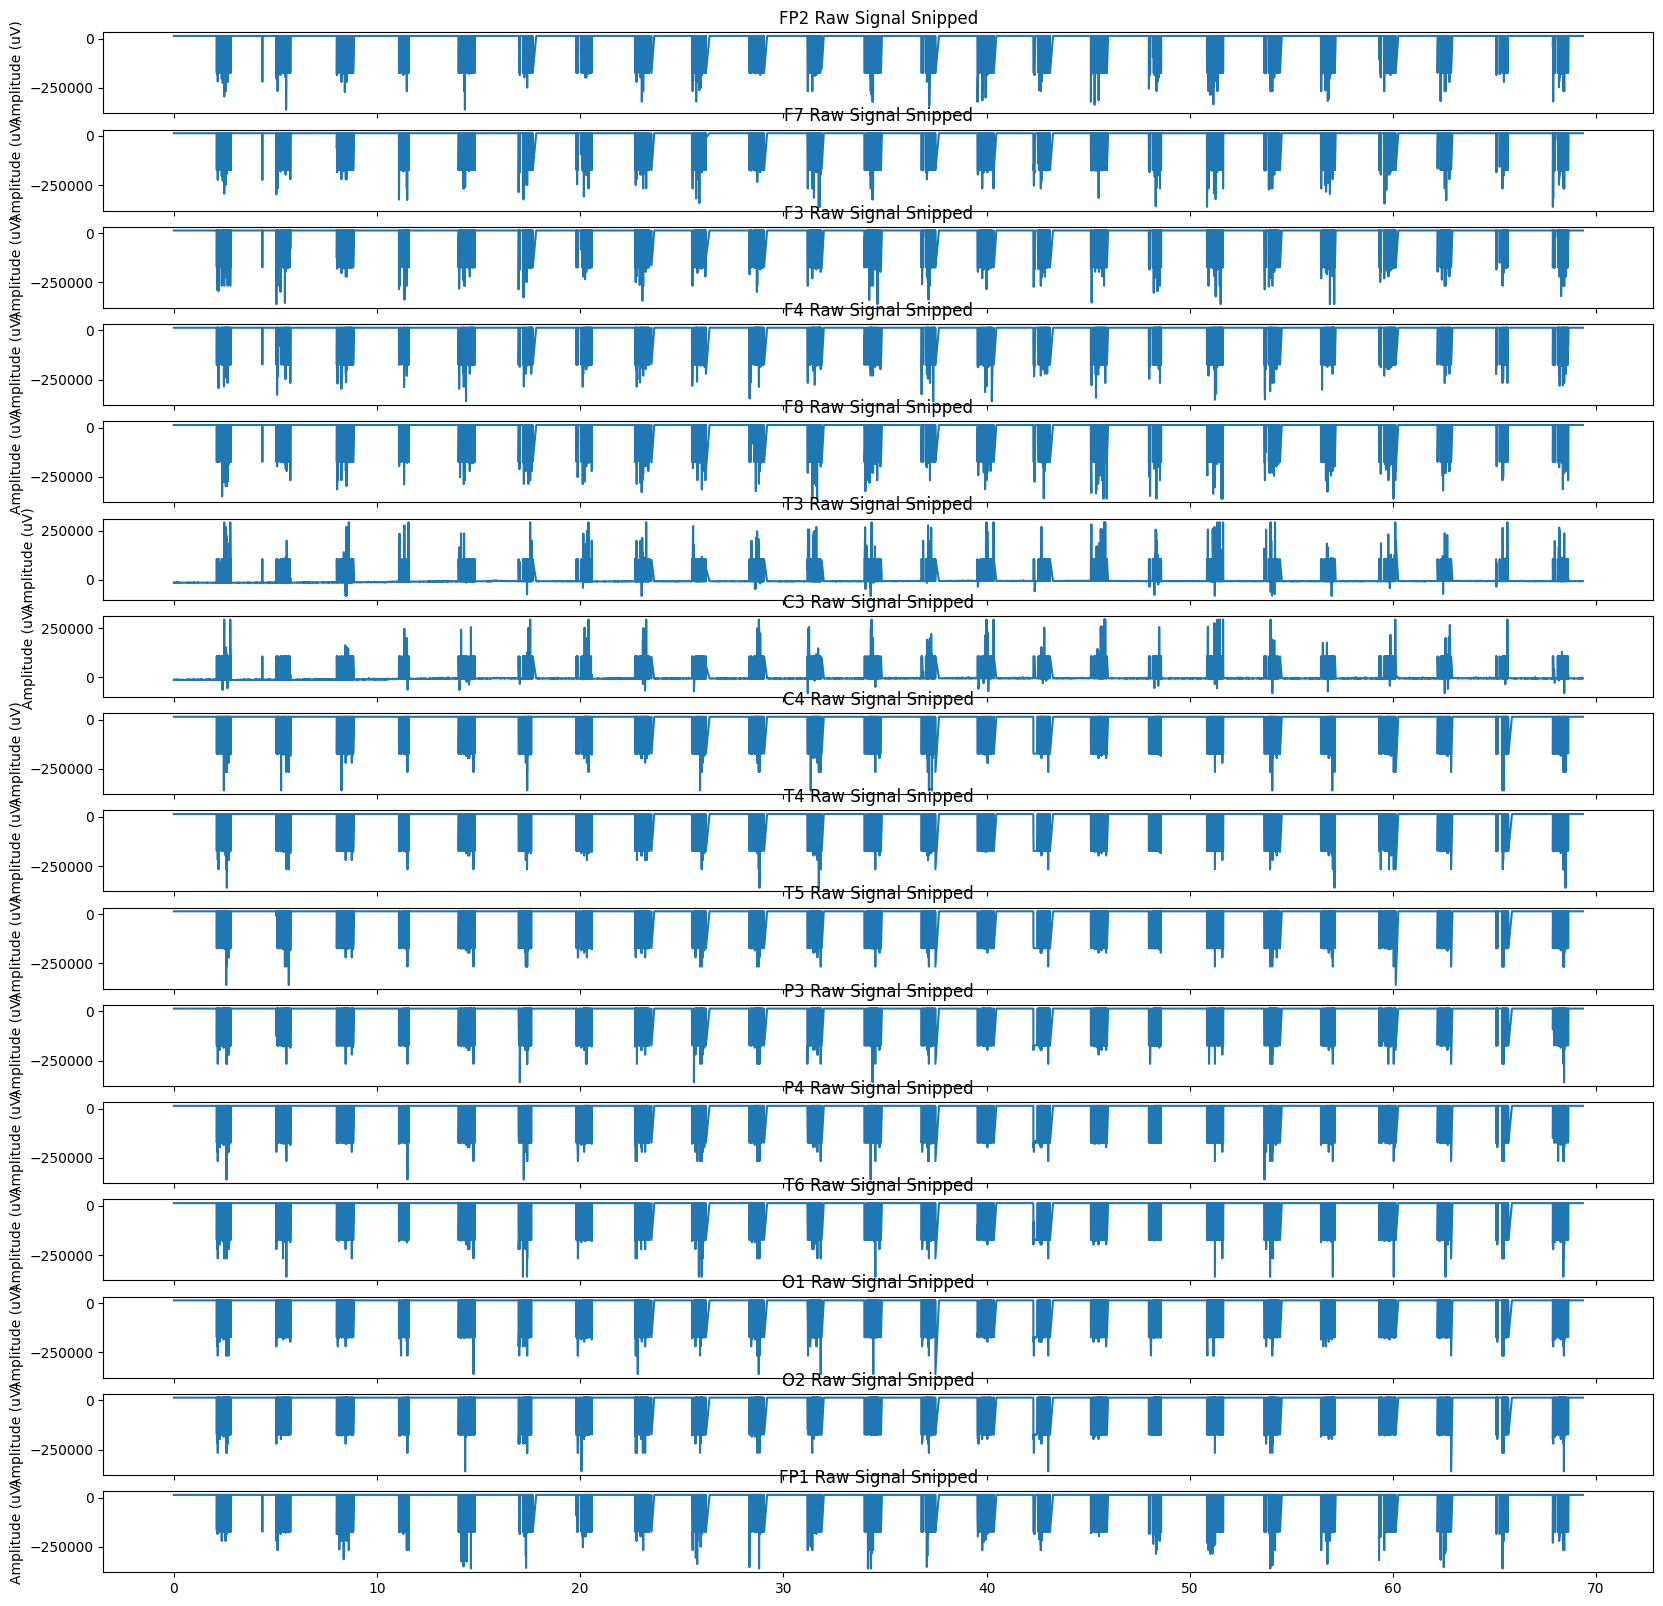

In [24]:
# after dropping last 10 seconds due to movement
music_eeg_df = music_eeg_df.iloc[:-10*fs]
fig, axes = plt.subplots(16,1, figsize=(20,20), sharex=True)
for i in range(len(channels)):
    axes[i-1].plot(music_eeg_df['timestamp_s'], music_eeg_df[f'{channels[i]}'])
    axes[i-1].set_title(f'{channels[i]} Raw Signal Snipped')
    # axes[i-1].set_xlabel('Timestamp (s)')
    axes[i-1].set_ylabel('Amplitude (uV)')

Text(0, 0.5, 'Amplitude (uV)')

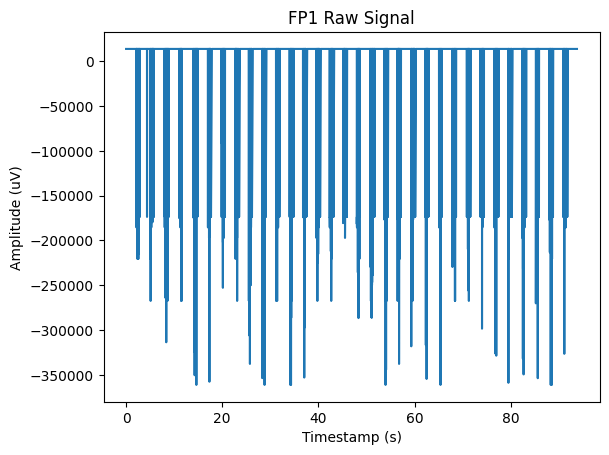

In [20]:
# individual channel:
plt.plot(music_eeg_df['timestamp_s'], music_eeg_df['FP1'])
plt.title('FP1 Raw Signal')
plt.xlabel('Timestamp (s)')
plt.ylabel('Amplitude (uV)')

Text(0, 0.5, 'Amplitude (uV)')

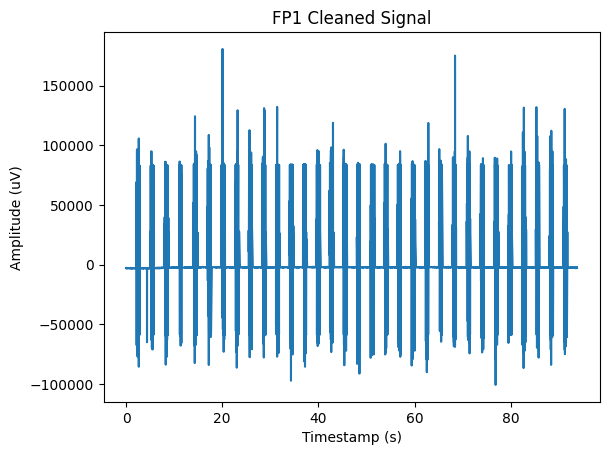

In [21]:
# now cleaning the eeg data with the butterworth bandpass filter
# print(music_df.iloc[:,1:].values)
# numpy array of shape (17906, 16) where each column is a channel and each row is a time point
cleaned_music_df = butter_bandpass_filter(music_eeg_df.iloc[:,1:].values, lowcut, highcut, fs, order=2)
cleaned_music_df_normalized = cleaned_music_df / np.max(np.abs(cleaned_music_df)) * np.max(np.abs(music_eeg_df.iloc[:,1:].values))


plt.plot(music_eeg_df['timestamp_s'], cleaned_music_df_normalized[:,15])
plt.title('FP1 Cleaned Signal')
plt.xlabel('Timestamp (s)')
plt.ylabel('Amplitude (uV)')

Text(0, 0.5, 'Amplitude (uV)')

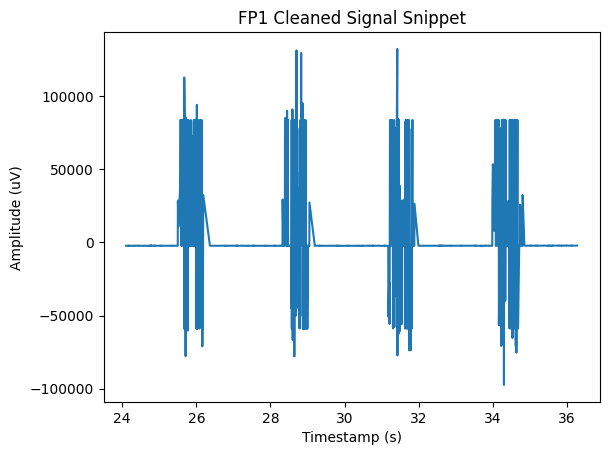

In [23]:
# get middle of the signal, from 10 to 30 seconds
plt.plot(music_eeg_df['timestamp_s'][10*fs:15*fs], cleaned_music_df_normalized[10*fs:15*fs,15])
plt.title('FP1 Cleaned Signal Snippet')
plt.xlabel('Timestamp (s)')
plt.ylabel('Amplitude (uV)')

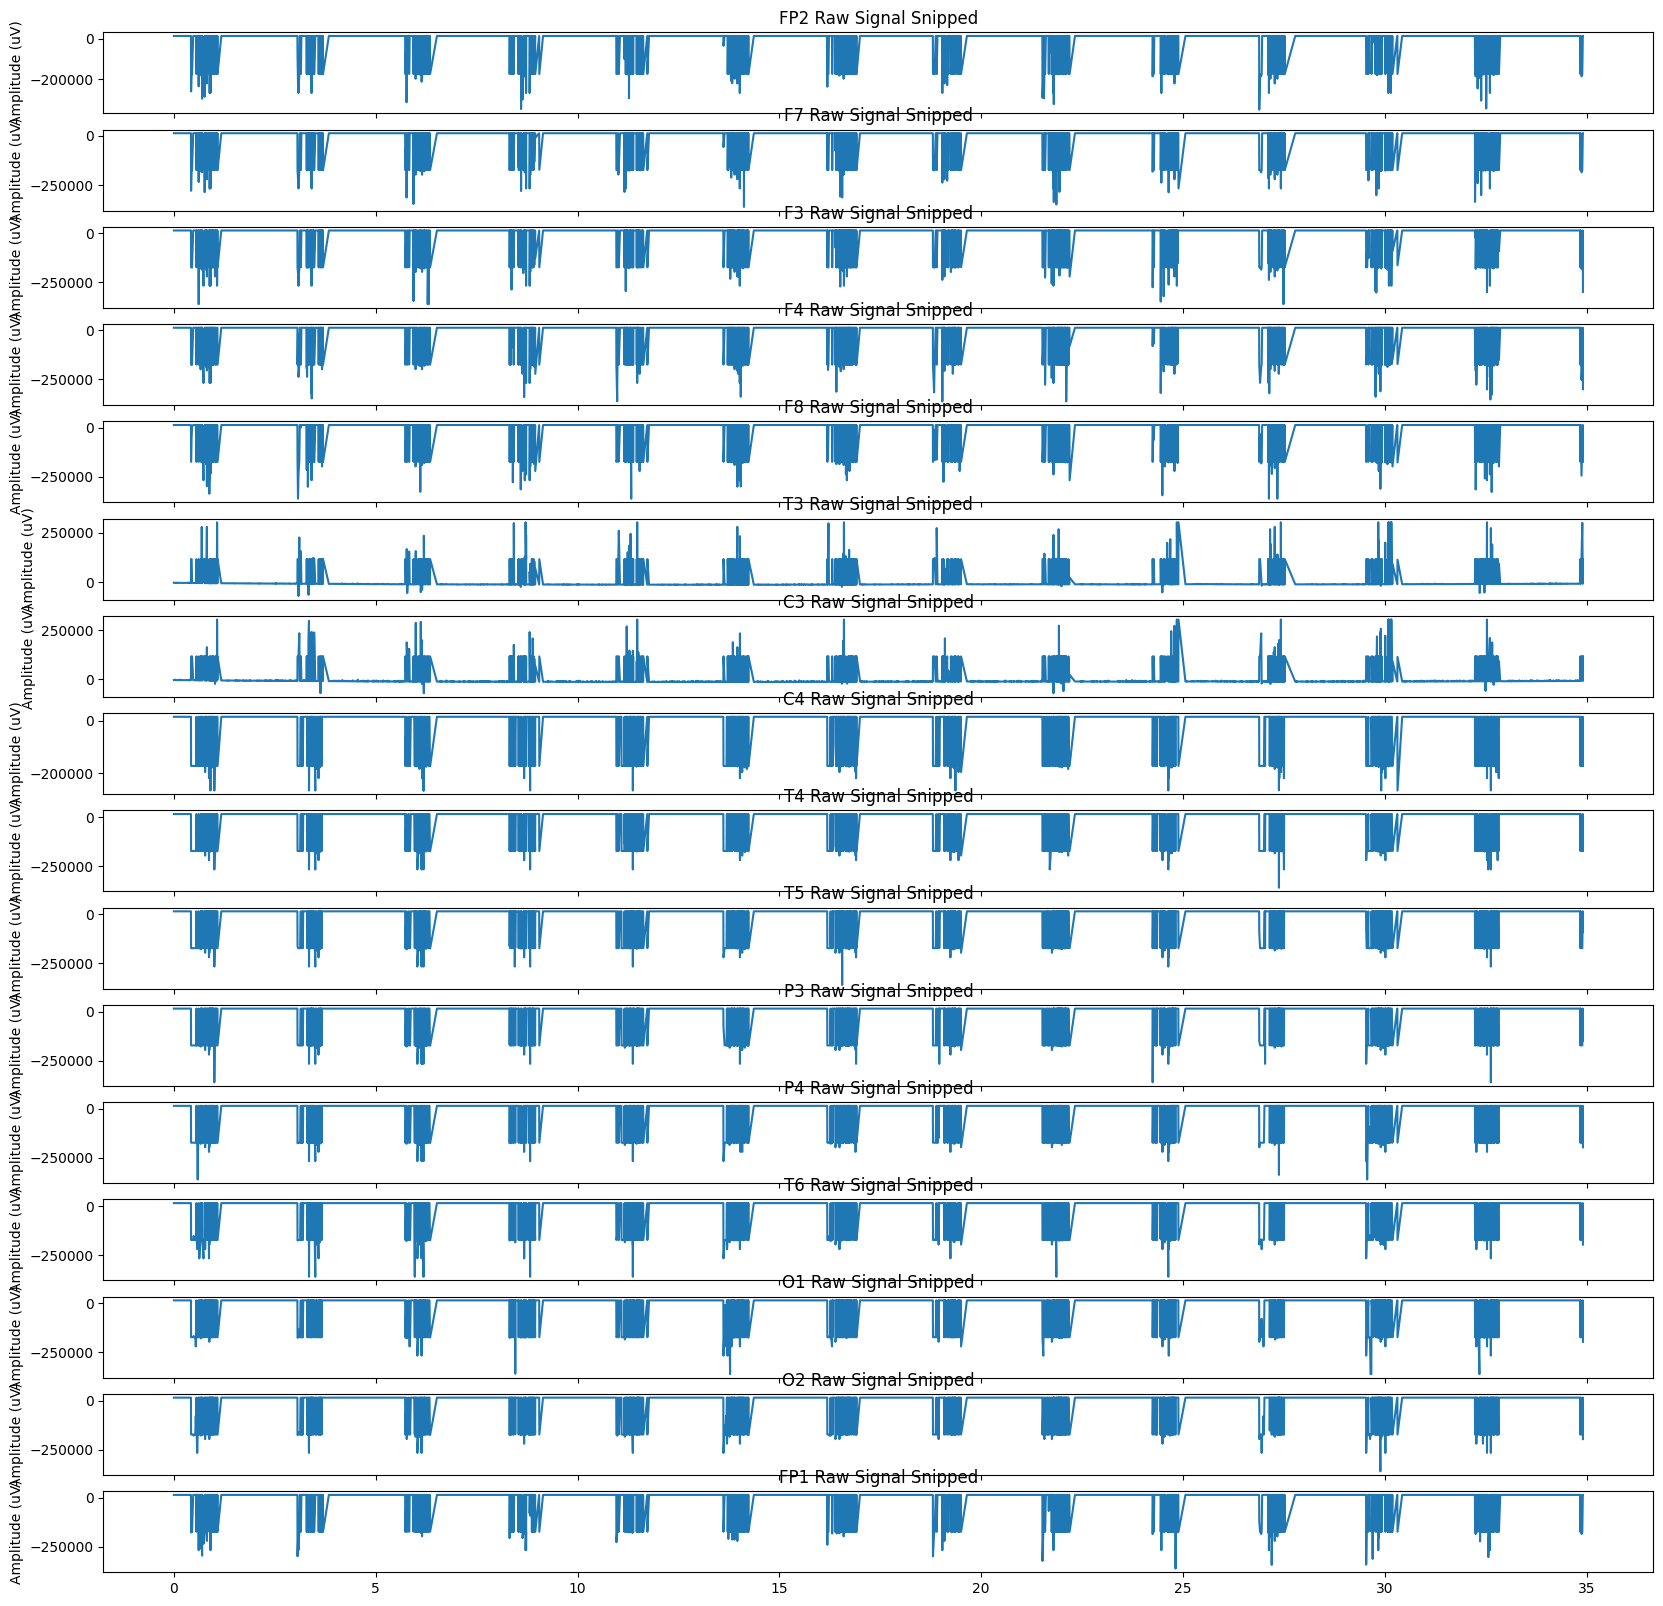

In [26]:
# after dropping last 10 seconds due to movement
global_baseline_eeg_df = global_baseline_eeg_df.iloc[:-10*fs]
fig, axes = plt.subplots(16,1, figsize=(20,20), sharex=True)
for i in range(len(channels)):
    axes[i-1].plot(global_baseline_eeg_df['timestamp_s'], global_baseline_eeg_df[f'{channels[i]}'])
    axes[i-1].set_title(f'{channels[i]} Raw Signal Snipped')
    # axes[i-1].set_xlabel('Timestamp (s)')
    axes[i-1].set_ylabel('Amplitude (uV)')

,timestamp_s,ch1_uV,ch2_uV,ch3_uV,ch4_uV,ch5_uV,ch6_uV,ch7_uV,ch8_uV,ch9_uV,ch10_uV,ch11_uV,ch12_uV,ch13_uV,ch14_uV,ch15_uV,ch16_uV
0,1849.718008,187500.0,187500.0,187500.0000,187500.0000,187500.0000,187500.0000,-119310.2812,-116018.4297,187500.0000,187500.0000,187500.0000,187500.0000,187500.0000,187500.0000,187500.0,187500.0
1,1849.721794,0.0,0.0,0.0000,0.0000,40.0543,11.4217,-11.4664,-11.4664,187500.0000,187500.0000,187500.0000,187500.0000,187500.0000,187500.0000,187500.0,187500.0
2,1849.726115,187500.0,187500.0,187500.0000,187500.0000,187500.0000,187500.0000,-120797.5703,-120642.4219,-5859.3979,-5859.3979,-5859.3979,-5859.3979,-11718.7510,0.0000,0.0,0.0
3,1849.738077,187500.0,187500.0,187500.0000,187500.0000,187500.0000,187500.0000,-120436.8125,-120492.0156,-1464.8663,-1464.8663,-1464.8663,-1464.8663,-1464.8663,-2929.6877,0.0,0.0
4,1849.741865,0.0,0.0,82031.2578,23437.4805,-23437.5254,-23437.5254,-23437.5254,-23437.5254,187500.0000,187500.0000,187500.0000,187500.0000,187500.0000,187500.0000,187500.0,187500.0
